# Background Suppression → Time to 3D + Optical Flow Comparison (skimage version)

**Pipeline:**
1. Read source video with OpenCV
2. Apply background subtraction **in-memory** (MOG2 or KNN) → foreground mask per frame
3. Optional Gaussian blur to reduce speckle noise
4. Stack masks → 3D volume `(T, H, W)`
5. **skimage Marching Cubes** iso-surface extraction
6. Plotly 3D interactive view → saved to `html/background_3d.html` (not shown inline)
7. Side-by-side **combined PNG** snapshot: original frame | foreground mask | 3D matplotlib projection
8. **Optical flow comparison** (Farneback / LK PyrLK / DIS / RLOF) on foreground masks
9. Benchmark table, flow magnitude chart, per-method flow snapshots

**Dependencies:** `pip install scikit-image opencv-contrib-python plotly numpy pandas matplotlib kaleido`


## 1 · Configuration

In [23]:
import os
import numpy as np
import cv2
import matplotlib
matplotlib.use('Agg')  # non-interactive backend — no inline display
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from skimage.measure import marching_cubes
import plotly.graph_objects as go
import time

# ── Path configuration (notebook lives in code/, outputs relative to repo root) ─
BASE_DIR   = os.path.join(os.path.dirname(os.path.abspath('__file__')), '..')
HTML_DIR   = os.path.join(BASE_DIR, 'html')
IMAGES_DIR = os.path.join(BASE_DIR, 'images')
VIDEO_DIR  = os.path.join(BASE_DIR, 'video')
os.makedirs(HTML_DIR,   exist_ok=True)
os.makedirs(IMAGES_DIR, exist_ok=True)

# ── Input video: OpenCV sample vtest.avi ─────────────────────────────────────
# Try OpenCV's sample finder first; if not installed, download from GitHub.
import urllib.request

_VTEST_URL  = 'https://raw.githubusercontent.com/opencv/opencv/master/samples/data/vtest.avi'
_VTEST_LOCAL = os.path.join(VIDEO_DIR, 'vtest.avi')

VIDEOFILE = cv2.samples.findFileOrKeep('vtest.avi')
if not VIDEOFILE or not os.path.isfile(VIDEOFILE):
    if not os.path.isfile(_VTEST_LOCAL):
        print(f'vtest.avi not found locally — downloading from OpenCV GitHub ...')
        urllib.request.urlretrieve(_VTEST_URL, _VTEST_LOCAL)
        print(f'Downloaded to {_VTEST_LOCAL}')
    else:
        print(f'Using cached {_VTEST_LOCAL}')
    VIDEOFILE = _VTEST_LOCAL
print(f'Video      : {VIDEOFILE}')

# ── Processing parameters ────────────────────────────────────────────────────
ALGO       = 'MOG2'     # 'MOG2' or 'KNN'
MAX_FRAMES = 80         # cap to keep memory sane (set None for full video)
BLUR_K     = 5          # Gaussian blur kernel size (odd int, 0 to disable)
FLIP_H     = True       # flip horizontally (matches original notebook)
ISO_LEVEL  = 192        # Marching Cubes threshold on the foreground mask (0-255)
STEP_SIZE  = 1          # MC step size (increase to 2 for faster/coarser)

print(f'Algorithm  : {ALGO}')
print(f'Max frames : {MAX_FRAMES}')
print(f'ISO level  : {ISO_LEVEL}')

Using cached /mnt/d/notebooks/RichnessGAN/../video/vtest.avi
Video      : /mnt/d/notebooks/RichnessGAN/../video/vtest.avi
Algorithm  : MOG2
Max frames : 80
ISO level  : 192


[ WARN:0@745.335] global samples.cpp:61 findFile cv::samples::findFile('vtest.avi') => ''


## 2 · Background Subtraction (in-memory, no intermediate video)

In [24]:
# ── Create background subtractor ──────────────────────────────────────────────
if ALGO == 'MOG2':
    back_sub = cv2.createBackgroundSubtractorMOG2()
else:
    back_sub = cv2.createBackgroundSubtractorKNN()

cap = cv2.VideoCapture(VIDEOFILE)
if not cap.isOpened():
    raise RuntimeError(f'Cannot open video: {VIDEOFILE}')

fps    = cap.get(cv2.CAP_PROP_FPS)
nf_tot = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f'Video: {nf_tot} frames @ {fps:.1f} fps')

orig_frames = []   # keep one original BGR frame per step for the snapshot
mask_frames = []   # foreground masks (uint8 grayscale)
count = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # ── Foreground mask ───────────────────────────────────────────────────────
    fg_mask = back_sub.apply(frame)           # uint8, values 0/128/255

    # ── Optional blur ─────────────────────────────────────────────────────────
    if BLUR_K > 0:
        fg_mask = cv2.GaussianBlur(fg_mask, (BLUR_K, BLUR_K), 0)

    # ── Optional horizontal flip ──────────────────────────────────────────────
    if FLIP_H:
        fg_mask = cv2.flip(fg_mask, 1)
        frame   = cv2.flip(frame,   1)

    orig_frames.append(frame.copy())
    mask_frames.append(fg_mask)
    count += 1
    if MAX_FRAMES and count >= MAX_FRAMES:
        break

cap.release()

# Stack masks into 3D volume: shape = (T, H, W)
volume = np.stack(mask_frames).astype(np.float32)
print(f'Frames read    : {len(mask_frames)}')
print(f'Volume shape   : {volume.shape}  (T, H, W)')
print(f'Mask value range: {volume.min():.0f} – {volume.max():.0f}')

Video: 795 frames @ 10.0 fps
Frames read    : 80
Volume shape   : (80, 576, 768)  (T, H, W)
Mask value range: 0 – 255


## 3 · Marching Cubes Iso-Surface

In [25]:
# ── Marching Cubes ─────────────────────────────────────────────────────────────
# verts  (N, 3): vertex coordinates in (T, Y, X) order
# faces  (M, 3): triangle vertex indices
# normals(N, 3): per-vertex unit normals
# values (N,)  : iso-value at each vertex
print(f'Running Marching Cubes (iso={ISO_LEVEL}, step={STEP_SIZE}) ...')
t0 = time.perf_counter()
verts, faces, normals, values = marching_cubes(
    volume,
    level=ISO_LEVEL,
    step_size=STEP_SIZE,
    allow_degenerate=False,
)
mc_time = time.perf_counter() - t0
print(f'Vertices : {verts.shape[0]:,}')
print(f'Faces    : {faces.shape[0]:,}')
print(f'MC time  : {mc_time:.3f} s')

# Coordinate mapping: verts = (T, Y, X)
t_coord = verts[:, 0]                          # Frame # axis
x_coord = verts[:, 2]                          # Width axis
y_coord = verts[:, 1].max() - verts[:, 1]      # Height (flipped so top=top)

Running Marching Cubes (iso=192, step=1) ...
Vertices : 370,754
Faces    : 738,218
MC time  : 0.538 s


## 4 · Plotly 3D — Save to HTML (no inline display)

In [26]:
# ── Plotly 3D mesh ────────────────────────────────────────────────────────────
fig = go.Figure(data=[
    go.Mesh3d(
        x=t_coord,
        y=x_coord,
        z=y_coord,
        colorbar_title='Frame #',
        colorscale=[
            [0.0, 'gold'],
            [0.2, 'mediumturquoise'],
            [1.0, 'magenta'],
        ],
        intensity=t_coord / max(t_coord.max(), 1),
        i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
        name='foreground surface',
        showscale=True,
        flatshading=False,
    )
])
fig.update_layout(
    title=dict(text=f'Background suppression → 3D  ({ALGO}, iso={ISO_LEVEL}) — rotate/zoom freely'),
    scene=dict(
        xaxis=dict(title='Frame #'),
        yaxis=dict(title='Width (px)'),
        zaxis=dict(title='Height (px)'),
        aspectmode='manual',
        aspectratio=dict(x=1, y=1, z=1),
    ),
    margin=dict(l=0, r=0, t=40, b=0),
)

HTML_PATH = os.path.join(HTML_DIR, 'background_3d.html')
fig.write_html(HTML_PATH)
print(f'Saved HTML : {HTML_PATH}')

# ── Static PNG via kaleido (optional) ────────────────────────────────────────
PNG_3D = os.path.join(IMAGES_DIR, 'background_3d.png')
try:
    fig.write_image(PNG_3D, width=1400, height=900, scale=2)
    print(f'Saved PNG  : {PNG_3D}')
except Exception as e:
    print(f'write_image skipped ({e}) — install kaleido: pip install kaleido')
    PNG_3D = None

Saved HTML : /mnt/d/notebooks/RichnessGAN/../html/background_3d.html
Saved PNG  : /mnt/d/notebooks/RichnessGAN/../images/background_3d.png


## 5 · Combined PNG Snapshot

Three-panel image replicating the layout from the reference screenshot:
- **Left**: original video frame (mid-sequence)
- **Centre**: foreground mask for the same frame
- **Right**: matplotlib 3D projection of the Marching Cubes surface

Combined PNG saved: /mnt/d/notebooks/RichnessGAN/../images/background_combined.png


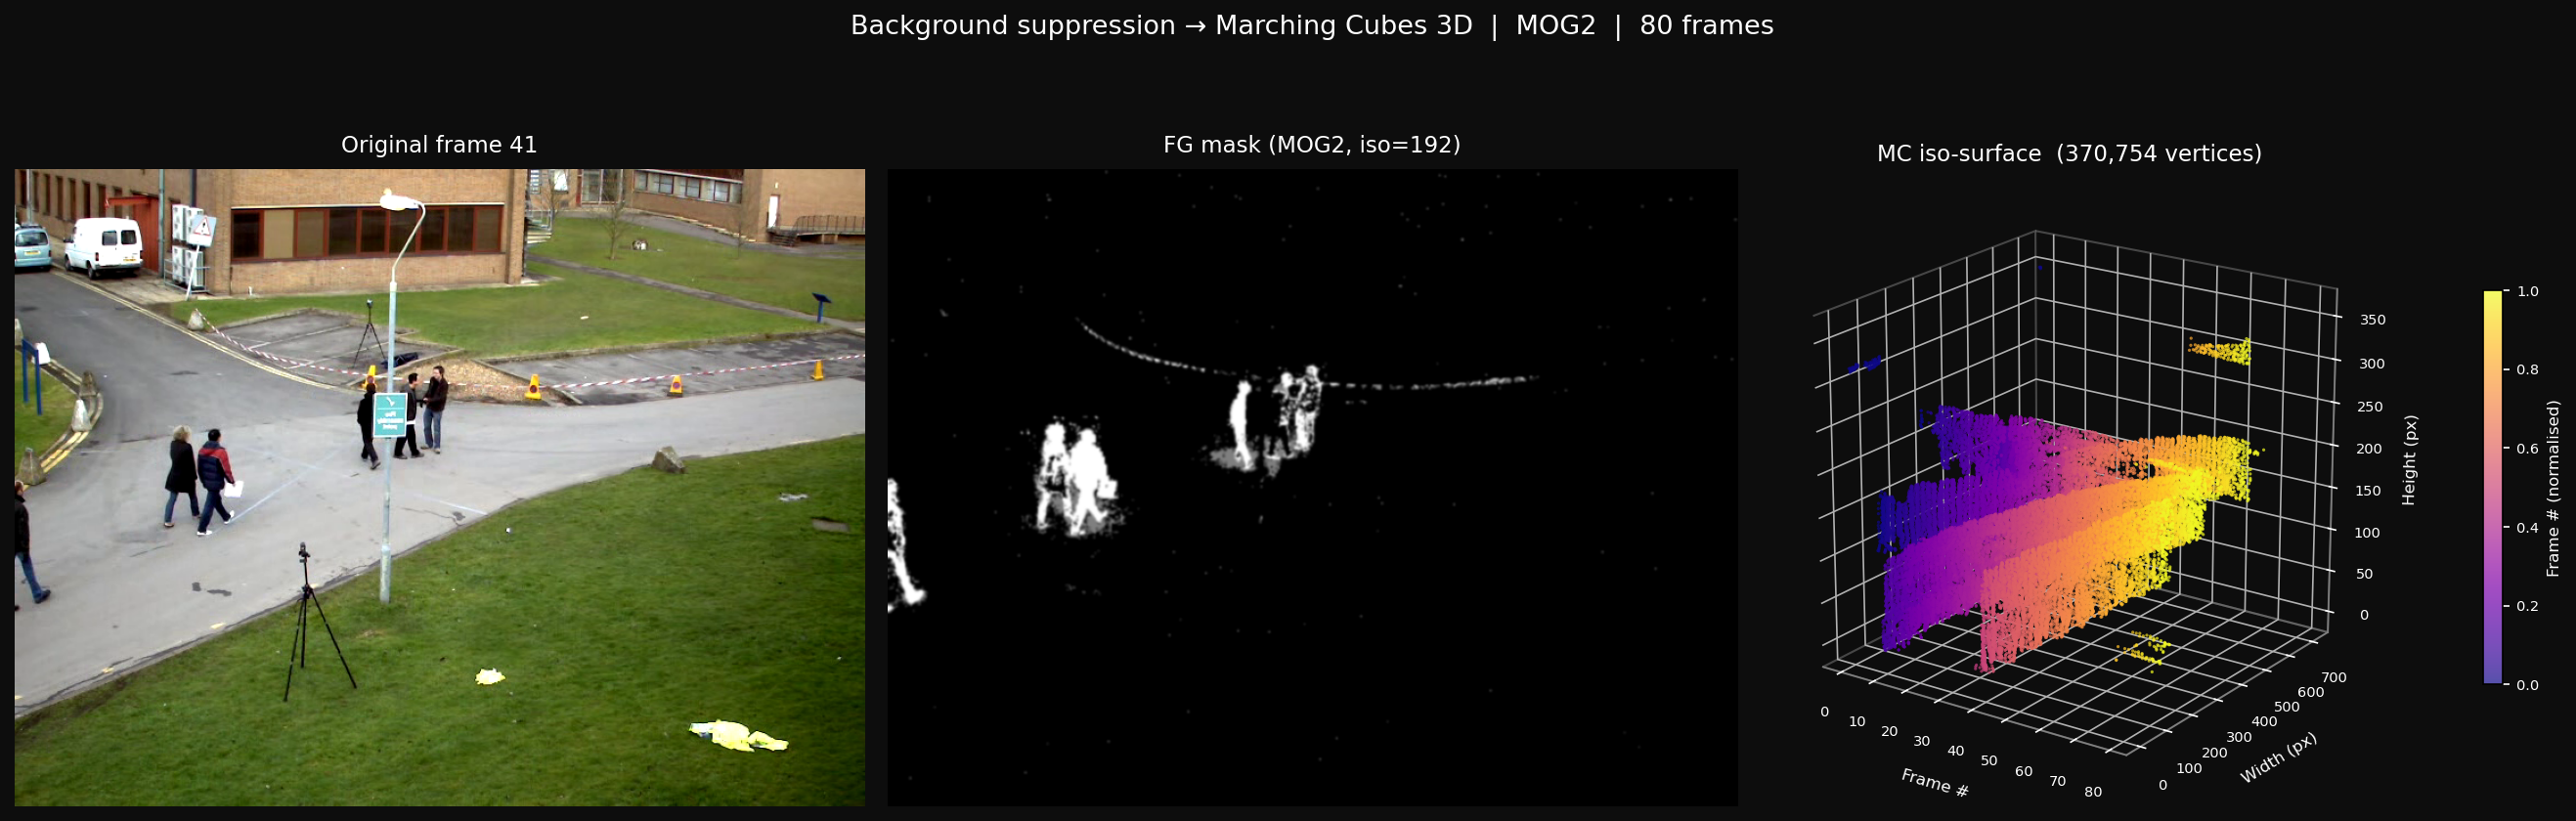

In [27]:
# ── Pick a representative mid-sequence frame ──────────────────────────────────
SNAP_FRAME = min(len(orig_frames) // 2, len(orig_frames) - 1)

orig_rgb = cv2.cvtColor(orig_frames[SNAP_FRAME], cv2.COLOR_BGR2RGB)
mask_rgb = cv2.cvtColor(mask_frames[SNAP_FRAME], cv2.COLOR_GRAY2RGB)

# ── Subsample vertices for the 3D scatter (every Nth point) ──────────────────
N_SCATTER = max(1, len(t_coord) // 40_000)   # target ~40k points
idx_s     = np.arange(0, len(t_coord), N_SCATTER)
intensity_s = t_coord[idx_s] / max(t_coord.max(), 1)

# ── Build the combined 3-panel figure ────────────────────────────────────────
fig_comb = plt.figure(figsize=(18, 6), facecolor='#0d0d0d')

# Panel 1 — original frame
ax1 = fig_comb.add_subplot(1, 3, 1)
ax1.imshow(orig_rgb)
ax1.set_title(f'Original frame {SNAP_FRAME + 1}',
              color='white', fontsize=11, pad=8)
ax1.axis('off')

# Panel 2 — foreground mask
ax2 = fig_comb.add_subplot(1, 3, 2)
ax2.imshow(mask_rgb)
ax2.set_title(f'FG mask ({ALGO}, iso={ISO_LEVEL})',
              color='white', fontsize=11, pad=8)
ax2.axis('off')

# Panel 3 — Marching Cubes 3D scatter
ax3 = fig_comb.add_subplot(1, 3, 3, projection='3d')
ax3.set_facecolor('#0d0d0d')
sc = ax3.scatter(
    t_coord[idx_s], x_coord[idx_s], y_coord[idx_s],
    c=intensity_s,
    cmap='plasma',   # gold→magenta feel on dark bg
    s=0.3, alpha=0.7,
)
ax3.set_xlabel('Frame #',    color='white', fontsize=8, labelpad=4)
ax3.set_ylabel('Width (px)', color='white', fontsize=8, labelpad=4)
ax3.set_zlabel('Height (px)',color='white', fontsize=8, labelpad=4)
ax3.tick_params(colors='white', labelsize=7)
ax3.xaxis.pane.fill = False
ax3.yaxis.pane.fill = False
ax3.zaxis.pane.fill = False
for spine in [ax3.xaxis, ax3.yaxis, ax3.zaxis]:
    spine.line.set_color('grey')
    spine.pane.set_edgecolor('grey')
ax3.view_init(elev=20, azim=-55)
ax3.set_box_aspect([1, 1, 1])
ax3.set_title(f'MC iso-surface  ({verts.shape[0]:,} vertices)',
              color='white', fontsize=11, pad=8)
cbar = fig_comb.colorbar(sc, ax=ax3, shrink=0.5, pad=0.12)
cbar.set_label('Frame # (normalised)', color='white', fontsize=8)
cbar.ax.yaxis.set_tick_params(color='white', labelsize=7)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

plt.suptitle(
    f'Background suppression → Marching Cubes 3D  |  {ALGO}  |  {len(mask_frames)} frames',
    color='white', fontsize=13, y=1.01
)
plt.tight_layout()

COMBINED_PNG = os.path.join(IMAGES_DIR, 'background_combined.png')
plt.savefig(COMBINED_PNG, dpi=150, bbox_inches='tight',
            facecolor=fig_comb.get_facecolor())
plt.close()
print(f'Combined PNG saved: {COMBINED_PNG}')

# ── Display inline (thumbnail only — does not embed the full Plotly HTML) ─────
from IPython.display import Image, display
display(Image(COMBINED_PNG, width=900))

## 6 · Optical Flow Comparison on Foreground Masks

Run the same 4 cv2 optical flow methods as in the echocardiography benchmark,
applied to the **foreground mask frames** (not the raw video).
Working on the mask rather than the original image isolates moving-object motion
from background texture, giving cleaner flow estimates.

| | Method | Type |
|---|---|---|
| **B** | Farneback | Dense 2D |
| **C** | Lucas-Kanade PyrLK | Sparse 2D (Shi-Tomasi corners) |
| **D** | DIS — Dense Inverse Search | Dense 2D |
| **E** | RLOF — Robust Local Optical Flow | Sparse 2D |


In [28]:
import time

HAS_RLOF = hasattr(cv2, 'optflow') and hasattr(cv2.optflow, 'calcOpticalFlowSparseRLOF')
print(f'RLOF available: {HAS_RLOF}  (requires opencv-contrib-python)')

# ── Shared parameters ────────────────────────────────────────────────────────
FLOW_THRESHOLD = 0.35   # px/frame — vectors below this are ignored in stats
volume_u8      = volume.astype(np.uint8)   # uint8 for cv2
n_frames       = volume_u8.shape[0]
H_v, W_v       = volume_u8.shape[1], volume_u8.shape[2]

ST_PARAMS = dict(maxCorners=500, qualityLevel=0.01, minDistance=7, blockSize=7)
LK_PARAMS = dict(winSize=(15, 15), maxLevel=3,
                 criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03))
FB_PARAMS = dict(pyr_scale=0.5, levels=3, winsize=15,
                 iterations=3, poly_n=5, poly_sigma=1.2, flags=0)

results = {}   # method_label → dict(time_s, magnitudes, n_pts)

# ── Method A: MC spatio-temporal gradient ───────────────────────────────────
# normals from marching_cubes are unit vectors: (dT, dY, dX)
# flow proxy = |dT| / (sqrt(dX²+dY²) + eps), clipped to [0, 50]
print('Computing Method A (MC gradient) ...')
t0 = time.perf_counter()
EPS   = 1e-6
dT_mc = normals[:, 0]
dY_mc = normals[:, 1]
dX_mc = normals[:, 2]
spatial_mag_mc  = np.sqrt(dX_mc**2 + dY_mc**2) + EPS
flow_mag_mc_raw = np.clip(np.abs(dT_mc) / spatial_mag_mc, 0, 50)
mc_grad_time    = time.perf_counter() - t0
# Aggregate into per-frame mean by binning vertices on their T coordinate
t_idx   = np.clip(np.round(verts[:, 0]).astype(int), 0, n_frames - 2)
mc_frame_means  = np.array([
    flow_mag_mc_raw[t_idx == f].mean() if (t_idx == f).any() else 0.0
    for f in range(n_frames - 1)
])
results['A — MC Gradient'] = dict(
    time_s=mc_grad_time,
    magnitudes=mc_frame_means,
    n_pts=len(verts),
    type='Sparse 3D',
)
print(f'  {mc_grad_time*1000:.2f} ms  ({len(verts):,} vertices)')


# ── Method B: Farneback ──────────────────────────────────────────────────────
print('Running Method B (Farneback) ...')
t0 = time.perf_counter()
fb_mags, fb_flows = [], []
for i in range(n_frames - 1):
    flow = cv2.calcOpticalFlowFarneback(volume_u8[i], volume_u8[i+1], None, **FB_PARAMS)
    mag, _ = cv2.cartToPolar(flow[..., 0], flow[..., 1])
    fb_mags.append(mag.mean())
    fb_flows.append(flow)
results['B — Farneback'] = dict(
    time_s=time.perf_counter()-t0, magnitudes=np.array(fb_mags),
    n_pts=(n_frames-1)*H_v*W_v, flows=fb_flows, type='Dense')
print(f'  {results["B — Farneback"]["time_s"]*1000:.1f} ms')

# ── Method C: LK PyrLK ───────────────────────────────────────────────────────
print('Running Method C (LK PyrLK) ...')
t0 = time.perf_counter()
lk_mags, lk_tracks, lk_npts = [], [], []
for i in range(n_frames - 1):
    p0 = cv2.goodFeaturesToTrack(volume_u8[i], mask=None, **ST_PARAMS)
    if p0 is None:
        lk_mags.append(0.0); lk_tracks.append((None, None)); lk_npts.append(0); continue
    p1, status, _ = cv2.calcOpticalFlowPyrLK(volume_u8[i], volume_u8[i+1], p0, None, **LK_PARAMS)
    good = status.ravel() == 1
    if good.sum() == 0:
        lk_mags.append(0.0); lk_tracks.append((None, None)); lk_npts.append(0); continue
    disp = (p1[good].astype(np.float64) - p0[good].astype(np.float64)).reshape(-1, 2)
    mag  = np.linalg.norm(disp, axis=1)
    lk_mags.append(mag.mean()); lk_tracks.append((p0[good], p1[good])); lk_npts.append(good.sum())
results['C — LK PyrLK'] = dict(
    time_s=time.perf_counter()-t0, magnitudes=np.array(lk_mags),
    n_pts=int(np.sum(lk_npts)), tracks=lk_tracks, type='Sparse')
print(f'  {results["C — LK PyrLK"]["time_s"]*1000:.1f} ms')

# ── Method D: DIS ────────────────────────────────────────────────────────────
print('Running Method D (DIS) ...')
dis = cv2.DISOpticalFlow_create(cv2.DISOpticalFlow_PRESET_FAST)
t0 = time.perf_counter()
dis_mags, dis_flows = [], []
for i in range(n_frames - 1):
    flow = dis.calc(volume_u8[i], volume_u8[i+1], None)
    mag, _ = cv2.cartToPolar(flow[..., 0], flow[..., 1])
    dis_mags.append(mag.mean())
    dis_flows.append(flow)
results['D — DIS'] = dict(
    time_s=time.perf_counter()-t0, magnitudes=np.array(dis_mags),
    n_pts=(n_frames-1)*H_v*W_v, flows=dis_flows, type='Dense')
print(f'  {results["D — DIS"]["time_s"]*1000:.1f} ms')

# ── Method E: RLOF ───────────────────────────────────────────────────────────
if HAS_RLOF:
    print('Running Method E (RLOF) ...')
    rlof_params = cv2.optflow.RLOFOpticalFlowParameter_create()
    rlof_params.setUseInitialFlow(False)
    t0 = time.perf_counter()
    rlof_mags, rlof_tracks, rlof_npts = [], [], []
    for i in range(n_frames - 1):
        prev_gray = volume_u8[i]
        curr_gray = volume_u8[i+1]
        prev_bgr  = cv2.cvtColor(prev_gray, cv2.COLOR_GRAY2BGR)
        curr_bgr  = cv2.cvtColor(curr_gray, cv2.COLOR_GRAY2BGR)
        p0 = cv2.goodFeaturesToTrack(prev_gray, mask=None, **ST_PARAMS)
        if p0 is None:
            rlof_mags.append(0.0); rlof_tracks.append((None,None)); rlof_npts.append(0); continue
        st = np.zeros((len(p0), 1), dtype=np.uint8)
        er = np.zeros((len(p0), 1), dtype=np.float32)
        p1, st, er = cv2.optflow.calcOpticalFlowSparseRLOF(prev_bgr, curr_bgr, p0, None, st, er, rlof_params)
        good = st.ravel() == 1
        if good.sum() == 0:
            rlof_mags.append(0.0); rlof_tracks.append((None,None)); rlof_npts.append(0); continue
        pts0 = p0[good].reshape(-1, 2).astype(np.float64)
        pts1 = p1[good].reshape(-1, 2).astype(np.float64)
        disp = np.clip(pts1 - pts0, -20, 20)
        pts1c = pts0 + disp
        mag = np.linalg.norm(disp, axis=1)
        mag = mag[np.isfinite(mag)]
        rlof_mags.append(mag.mean() if len(mag) else 0.0)
        rlof_tracks.append((pts0, pts1c)); rlof_npts.append(good.sum())
    results['E — RLOF'] = dict(
        time_s=time.perf_counter()-t0, magnitudes=np.array(rlof_mags),
        n_pts=int(np.sum(rlof_npts)), tracks=rlof_tracks, type='Sparse')
    print(f'  {results["E — RLOF"]["time_s"]*1000:.1f} ms')
else:
    print('Method E (RLOF) skipped — install opencv-contrib-python')

print('\nAll methods done.')


RLOF available: True  (requires opencv-contrib-python)
Computing Method A (MC gradient) ...
  5.16 ms  (370,754 vertices)
Running Method B (Farneback) ...
  6983.4 ms
Running Method C (LK PyrLK) ...
  433.4 ms
Running Method D (DIS) ...
  544.1 ms
Running Method E (RLOF) ...
  1854.1 ms

All methods done.


## 7 · Benchmark Results & Flow Magnitude Chart


In [29]:
import pandas as pd

# ── Performance table ────────────────────────────────────────────────────────
def ns_per(t, n): return round(t / n * 1e9, 2) if n > 0 else float('nan')

rows = []
for label, r in results.items():
    m = r['magnitudes']
    rows.append({
        'Method'    : label,
        'Type'      : r['type'],
        'Time (ms)' : round(r['time_s'] * 1000, 2),
        'ns/point'  : ns_per(r['time_s'], r['n_pts']),
        'Flow mean' : round(float(m.mean()), 4),
        'Flow std'  : round(float(m.std()),  4),
        'Flow max'  : round(float(m.max()),  4),
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

# ── Flow magnitude over time ──────────────────────────────────────────────────
import plotly.graph_objects as go
from plotly.subplots import make_subplots

frame_idx = np.arange(n_frames - 1)
COLORS = {'A — MC Gradient': 'crimson',
          'B — Farneback': 'royalblue', 'C — LK PyrLK': 'darkorange',
          'D — DIS': 'green', 'E — RLOF': 'purple'}

fig_flow = go.Figure()
for label, r in results.items():
    fig_flow.add_trace(go.Scatter(
        x=frame_idx, y=r['magnitudes'],
        mode='lines', name=label, line=dict(color=COLORS.get(label, 'grey'))
    ))
# MC gradient global mean as reference line
if 'A — MC Gradient' in results:
    mc_mean = results['A — MC Gradient']['magnitudes'].mean()
    fig_flow.add_hline(y=mc_mean, line_dash='dash', line_color='crimson',
                       annotation_text=f'A — MC gradient mean ({mc_mean:.2f})',
                       annotation_position='top left')

fig_flow.update_layout(
    title='Optical flow magnitude over time — background mask',
    xaxis_title='Frame pair #', yaxis_title='Mean flow magnitude (px/frame)',
    height=420, legend=dict(x=0.01, y=0.99),
)
FLOW_HTML = os.path.join(HTML_DIR, 'bg_flow_all_methods.html')
fig_flow.write_html(FLOW_HTML)
print(f'Saved: {FLOW_HTML}')
try:
    fig_flow.write_image(os.path.join(IMAGES_DIR, 'bg_flow_all_methods.png'), width=1400, height=500, scale=2)
except Exception as e:
    print(f'write_image skipped ({e})')

# ── Performance bar charts ────────────────────────────────────────────────────
methods_l = df['Method'].tolist()
bar_colors = [COLORS.get(m, 'grey') for m in methods_l]
fig_bench = make_subplots(rows=1, cols=2,
    subplot_titles=('Total computation time (ms)', 'Cost per data point (ns)'))
fig_bench.add_trace(go.Bar(x=methods_l, y=df['Time (ms)'].tolist(),
    marker_color=bar_colors, showlegend=False,
    text=df['Time (ms)'].tolist(), textposition='outside'), row=1, col=1)
fig_bench.add_trace(go.Bar(x=methods_l, y=df['ns/point'].tolist(),
    marker_color=bar_colors, showlegend=False,
    text=[f'{v:.1f}' if not np.isnan(v) else 'N/A' for v in df['ns/point']],
    textposition='outside'), row=1, col=2)
fig_bench.update_yaxes(title_text='ms', row=1, col=1)
fig_bench.update_yaxes(title_text='ns', row=1, col=2)
fig_bench.update_layout(title='Optical flow benchmark — background mask', height=420)
BENCH_HTML = os.path.join(HTML_DIR, 'bg_flow_benchmark.html')
fig_bench.write_html(BENCH_HTML)
print(f'Saved: {BENCH_HTML}')
try:
    fig_bench.write_image(os.path.join(IMAGES_DIR, 'bg_flow_benchmark.png'), width=1400, height=500, scale=2)
except Exception as e:
    print(f'write_image skipped ({e})')


         Method      Type  Time (ms)  ns/point  Flow mean  Flow std  Flow max
A — MC Gradient Sparse 3D       5.16     13.91     9.2857    3.9809   20.9167
  B — Farneback     Dense    6983.38    199.83     0.4136    0.2390    1.6777
   C — LK PyrLK    Sparse     433.38  19008.58     6.7371   15.0126  134.0584
        D — DIS     Dense     544.08     15.57     3.0601    2.9798   21.4285
       E — RLOF    Sparse    1854.14  80611.18    11.2281   12.6520   28.2558
Saved: /mnt/d/notebooks/RichnessGAN/../html/bg_flow_all_methods.html
Saved: /mnt/d/notebooks/RichnessGAN/../html/bg_flow_benchmark.html


## 8 · Per-Method Flow Snapshots (Frame 2)

Dense methods (B, D): HSV colour-wheel overlay on the foreground mask — hue=direction, value=magnitude, black=below threshold.
Sparse methods (C, E): displacement arrows on original frame.


Saved: /mnt/d/notebooks/RichnessGAN/../images/bg_flow_snapshots.png


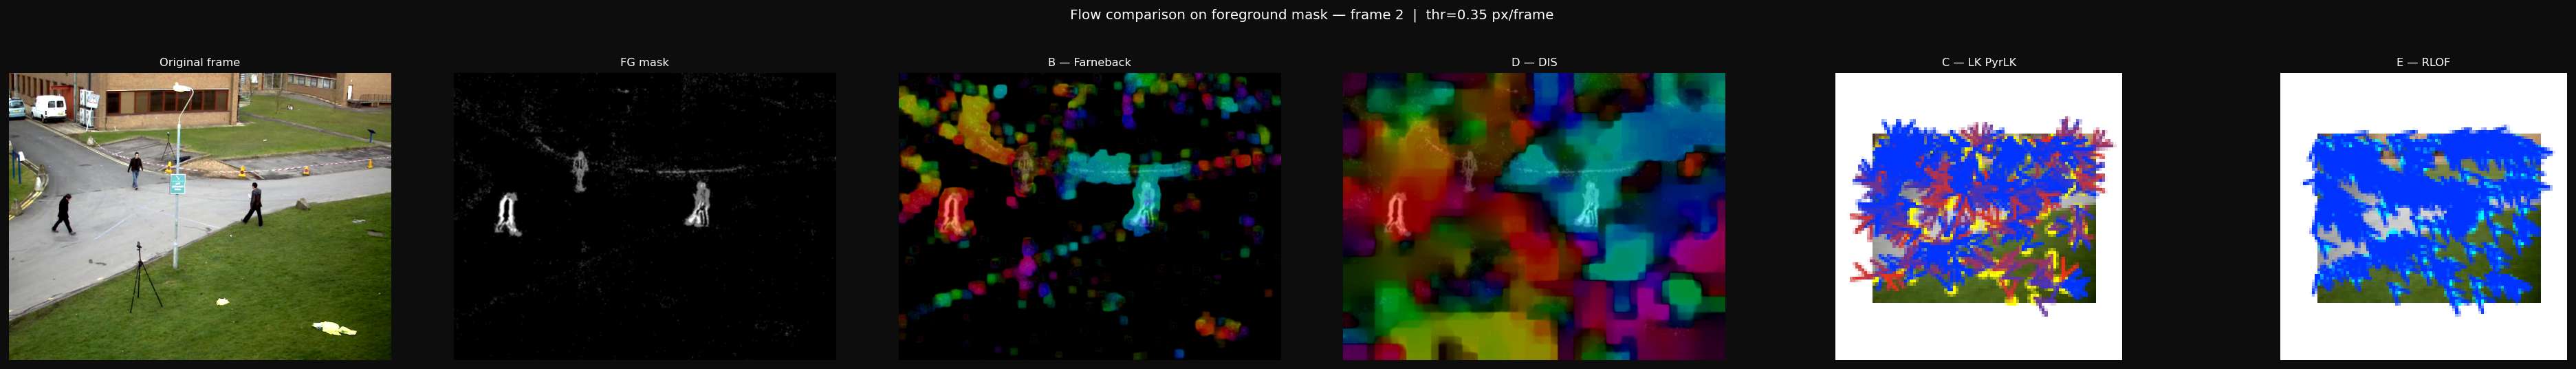

In [30]:
SNAP_FRAME = 1   # use frame pair 1→2
ABS_CAP    = 5.0  # px/frame cap for HSV colour scale on mask flow

def flow_to_hsv(flow, threshold=FLOW_THRESHOLD, cap=ABS_CAP):
    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1], angleInDegrees=True)
    hsv = np.zeros((*flow.shape[:2], 3), dtype=np.uint8)
    hsv[..., 0] = (ang / 2).astype(np.uint8)
    hsv[..., 1] = 255
    hsv[..., 2] = np.clip(mag / cap * 255, 0, 255).astype(np.uint8)
    hsv[mag < threshold, 2] = 0
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR), mag

orig_bgr  = orig_frames[SNAP_FRAME]
orig_rgb2 = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB)
mask_bgr  = cv2.cvtColor(volume_u8[SNAP_FRAME], cv2.COLOR_GRAY2BGR)

snap_panels = []   # (title, image_rgb)
snap_panels.append(('Original frame', orig_rgb2))
snap_panels.append(('FG mask', cv2.cvtColor(volume_u8[SNAP_FRAME], cv2.COLOR_GRAY2RGB)))

# Dense methods — HSV overlay on mask
for label, flows_key in [('B — Farneback', 'flows'), ('D — DIS', 'flows')]:
    if label not in results: continue
    flow = results[label][flows_key][SNAP_FRAME]
    flow_bgr, _ = flow_to_hsv(flow)
    comp = cv2.addWeighted(mask_bgr, 0.45, flow_bgr, 0.55, 0)
    snap_panels.append((label, cv2.cvtColor(comp, cv2.COLOR_BGR2RGB)))

# Sparse methods — arrow overlay on original frame
for label, tracks_key in [('C — LK PyrLK', 'tracks'), ('E — RLOF', 'tracks')]:
    if label not in results: continue
    p0g, p1g = results[label][tracks_key][SNAP_FRAME]
    canvas = orig_rgb2.copy()
    if p0g is not None and len(p0g) > 0:
        pts0 = np.array(p0g).reshape(-1, 2).astype(np.float64)
        pts1 = np.array(p1g).reshape(-1, 2).astype(np.float64)
        disp = np.clip(pts1 - pts0, -20, 20)
        pts1c = pts0 + disp
        mags = np.linalg.norm(disp, axis=1)
        fig_tmp, ax_tmp = plt.subplots(figsize=(1,1))
        ax_tmp.imshow(canvas)
        for pt0, pt1c, m in zip(pts0, pts1c, mags):
            if m < FLOW_THRESHOLD: continue
            ratio = min(m / 10.0, 1.0)
            color = (1.0-ratio, 0.2, ratio)
            ax_tmp.annotate('', xy=tuple(pt1c), xytext=tuple(pt0),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.0))
            ax_tmp.plot(pt0[0], pt0[1], 'o',
                color='yellow' if 'LK' in label else 'cyan', ms=2)
        ax_tmp.axis('off')
        fig_tmp.canvas.draw()
        w_c, h_c = fig_tmp.canvas.get_width_height()
        # tostring_rgb removed in matplotlib 3.8 → use buffer_rgba and drop alpha
        arr_rgba = np.frombuffer(fig_tmp.canvas.buffer_rgba(), dtype=np.uint8).reshape(h_c, w_c, 4)
        plt.close(fig_tmp)
        canvas = arr_rgba[..., :3]   # drop alpha channel → RGB
    snap_panels.append((label, canvas))

# ── Render all panels in one figure ──────────────────────────────────────────
n_panels = len(snap_panels)
fig_snaps, axes = plt.subplots(1, n_panels, figsize=(5*n_panels, 4),
                                facecolor='#0d0d0d')
if n_panels == 1: axes = [axes]
for ax, (title, img) in zip(axes, snap_panels):
    ax.imshow(img)
    ax.set_title(title, color='white', fontsize=9, pad=6)
    ax.axis('off')
plt.suptitle(f'Flow comparison on foreground mask — frame {SNAP_FRAME+1}  |  thr={FLOW_THRESHOLD} px/frame',
             color='white', fontsize=11, y=1.02)
plt.tight_layout()
SNAP_ALL = os.path.join(IMAGES_DIR, 'bg_flow_snapshots.png')
plt.savefig(SNAP_ALL, dpi=130, bbox_inches='tight', facecolor=fig_snaps.get_facecolor())
plt.close()
print(f'Saved: {SNAP_ALL}')
from IPython.display import Image, display
display(Image(SNAP_ALL, width=900))


## Summary

### Outputs

| File | Location | Description |
|---|---|---|
| `background_3d.html` | `html/` | Interactive Plotly 3D iso-surface (rotate/zoom) |
| `background_3d.png` | `images/` | Static kaleido snapshot of the 3D view |
| `background_combined.png` | `images/` | Three-panel: original \| FG mask \| 3D scatter |
| `bg_flow_all_methods.html` | `html/` | Flow magnitude over time — all methods |
| `bg_flow_benchmark.html` | `html/` | Performance bar charts |
| `bg_flow_all_methods.png` | `images/` | Static flow magnitude chart |
| `bg_flow_benchmark.png` | `images/` | Static benchmark bar charts |
| `bg_flow_snapshots.png` | `images/` | Per-method flow overlay snapshots (frame 2) |

### Pipeline summary

```
Video → Background subtraction (MOG2/KNN) → foreground masks (in-memory)
      → Gaussian blur → stack → Marching Cubes → Plotly 3D HTML
      → Optical flow (B/C/D/E) on masks → benchmark + snapshots
```

### Why optical flow on the foreground mask?

Running optical flow on the background-subtracted mask rather than the raw video has two advantages:
- **Cleaner signal**: static background textures do not contribute to the flow estimate
- **Lower computational cost**: the mask is binary-like (mostly 0), so dense methods work on a sparse signal

The approach generalises to any 2D video — traffic, industrial conveyor, crowd monitoring, sports biomechanics.
